In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cpu


In [20]:
X_train = np.load('../data/X_train.npy')
y_train = np.load('../data/y_train.npy')
X_test  = np.load('../data/X_test.npy')
y_test  = np.load('../data/y_test.npy')

# Convert to PyTorch tensors
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).to(device)
X_test_t  = torch.FloatTensor(X_test).to(device)
y_test_t  = torch.FloatTensor(y_test).to(device)

print("X_train_t shape:", X_train_t.shape) 
print("y_train_t shape:", y_train_t.shape) 

X_train_t shape: torch.Size([17731, 30, 14])
y_train_t shape: torch.Size([17731])


In [21]:
BATCH_SIZE = 256

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, 
                           batch_size=BATCH_SIZE, 
                           shuffle=True)

print(f"Total batches per epoch: {len(train_loader)}")

Total batches per epoch: 70


In [22]:
class RULPredictor(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super(RULPredictor, self).__init__()
        
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0
        )
        
        self.regressor = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )
    
    def forward(self, x):
        # x shape: (batch, 30, 14)
        lstm_out, _ = self.lstm(x)
        
        # Take only the last timestep output
        # Shape goes from (batch, 30, hidden) to (batch, hidden)
        last_timestep = lstm_out[:, -1, :]
        
        output = self.regressor(last_timestep)
        return output.squeeze()

# Instantiate the model
INPUT_SIZE  = 14   # number of sensors
HIDDEN_SIZE = 128  # memory cells inside LSTM
NUM_LAYERS  = 2    # stacked LSTM layers
DROPOUT     = 0.2  # regularisation

model = RULPredictor(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

RULPredictor(
  (lstm): LSTM(14, 128, num_layers=2, batch_first=True, dropout=0.2)
  (regressor): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total parameters: 214,145


In [23]:
criterion = nn.MSELoss()
optimiser = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiser, 
    mode     = 'min',
    factor   = 0.5,
    patience = 5,
    verbose  = True
)

In [26]:
EPOCHS = 50
train_losses = []
test_losses  = []

for epoch in range(EPOCHS):
    
    # --- Training phase ---
    model.train()
    batch_losses = []
    
    for X_batch, y_batch in train_loader:
        optimiser.zero_grad()
        
        predictions = model(X_batch)
        loss        = criterion(predictions, y_batch)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimiser.step()
        
        batch_losses.append(loss.item())
    
    train_loss = np.mean(batch_losses)
    train_losses.append(train_loss)
    
    # --- Evaluation phase ---
    model.eval()
    with torch.no_grad():
        test_preds = model(X_test_t)
        test_loss  = criterion(test_preds, y_test_t).item()
        test_losses.append(test_loss)
    
    scheduler.step(test_loss)
    
    if (epoch + 1) % 10 == 0:
        train_rmse = np.sqrt(train_loss)
        test_rmse  = np.sqrt(test_loss)
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
              f"Train RMSE: {train_rmse:.2f} | "
              f"Test RMSE: {test_rmse:.2f}")

print("\nTraining complete.")

KeyboardInterrupt: 

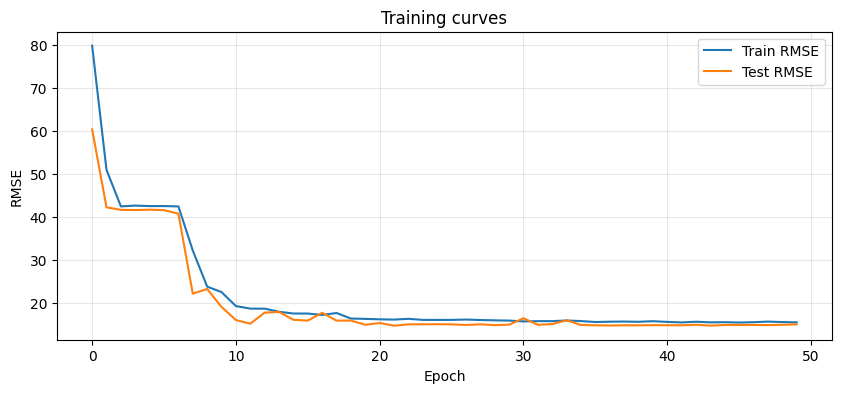

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(np.sqrt(train_losses), label='Train RMSE')
plt.plot(np.sqrt(test_losses),  label='Test RMSE')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.title('Training curves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
model.eval()
with torch.no_grad():
    y_pred = model(X_test_t).cpu().numpy()

y_test_np = y_test_t.cpu().numpy()
rmse = np.sqrt(mean_squared_error(y_test_np, y_pred))
print(f"LSTM Test RMSE: {rmse:.2f} cycles")
print(f"XGBoost Baseline: 14.26 cycles")
print(f"Improvement: {14.26 - rmse:.2f} cycles")

LSTM Test RMSE: 15.11 cycles
XGBoost Baseline: 14.26 cycles
Improvement: -0.85 cycles


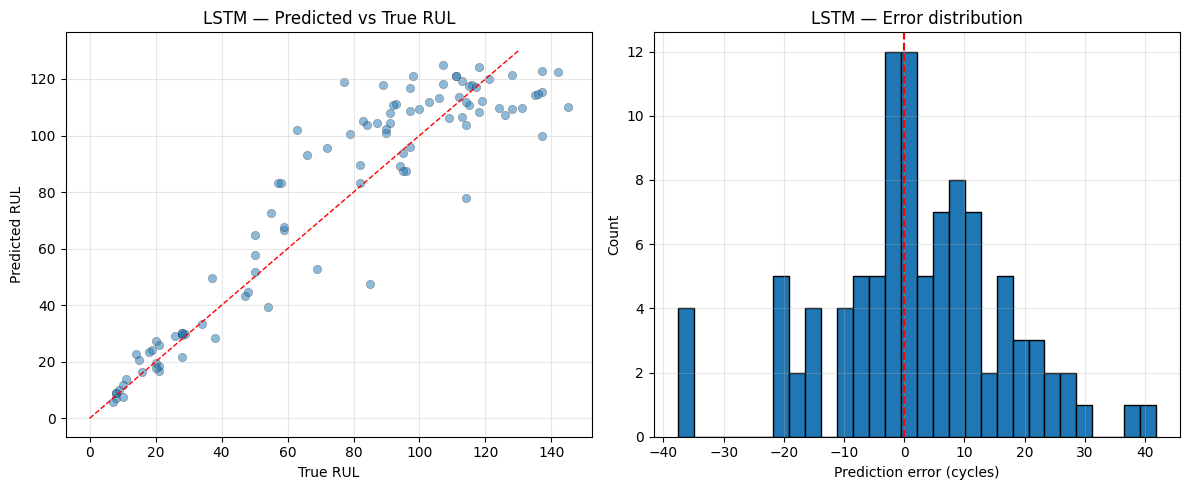

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test_np, y_pred, alpha=0.5, 
                edgecolors='k', linewidth=0.3)
axes[0].plot([0, 130], [0, 130], 'r--', linewidth=1)
axes[0].set_xlabel('True RUL')
axes[0].set_ylabel('Predicted RUL')
axes[0].set_title('LSTM — Predicted vs True RUL')
axes[0].grid(True, alpha=0.3)

errors = y_pred - y_test_np
axes[1].hist(errors, bins=30, edgecolor='black')
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_xlabel('Prediction error (cycles)')
axes[1].set_ylabel('Count')
axes[1].set_title('LSTM — Error distribution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
torch.save(model.state_dict(), '../models/lstm_model.pt')
print("LSTM model saved.")

LSTM model saved.


In [ ]:
# --- Tuning attempt 1 ---

class RULPredictorV2(nn.Module):
    def __init__(self):
        super(RULPredictorV2, self).__init__()
        
        self.lstm = nn.LSTM(
            input_size  = 14,
            hidden_size = 256,    # doubled from 128
            num_layers  = 3,      # added a third layer
            batch_first = True,
            dropout     = 0.3     # slightly more dropout to handle extra capacity
        )
        
        self.regressor = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )
    
    def forward(self, x):
        lstm_out, _   = self.lstm(x)
        last_timestep = lstm_out[:, -1, :]
        return self.regressor(last_timestep).squeeze()

model_v2  = RULPredictorV2().to(device)
criterion = nn.MSELoss()
optimiser = torch.optim.Adam(model_v2.parameters(), lr=0.001)  # halved lr
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiser, 
    mode     = 'min', 
    factor   = 0.5, 
    patience = 10,    # scheduler patience unchanged
    verbose  = True
)

print(model_v2)
print(f"Total parameters: {sum(p.numel() for p in model_v2.parameters()):,}")

RULPredictorV2(
  (lstm): LSTM(14, 256, num_layers=3, batch_first=True, dropout=0.3)
  (regressor): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)
Total parameters: 1,372,417


In [28]:
# Reinitialise everything from scratch before training
model_v2  = RULPredictorV2().to(device)
optimiser = torch.optim.Adam(model_v2.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiser, mode='min', factor=0.5, patience=10, verbose=True
)
early_stopping = EarlyStopping(patience=20, min_delta=0.05)
best_rmse      = float('inf')
train_losses   = []
test_losses    = []

print("Model reinitialised from scratch.")
print(f"Parameters: {sum(p.numel() for p in model_v2.parameters()):,}")

Model reinitialised from scratch.
Parameters: 1,372,417


/Users/ardacakil/Desktop/RUL-predictor/venv/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


In [31]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.1):
        self.patience    = patience
        self.min_delta   = min_delta
        self.counter     = 0
        self.best_loss   = float('inf')
        self.should_stop = False

    def check(self, loss):
        if loss < self.best_loss - self.min_delta:
            self.best_loss = loss
            self.counter   = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

In [32]:
model_v2  = RULPredictorV2().to(device)
optimiser = torch.optim.Adam(model_v2.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiser, mode='min', factor=0.5, patience=10, verbose=True
)
early_stopping = EarlyStopping(patience=20, min_delta=0.05)
best_rmse      = float('inf')
train_losses   = []
test_losses    = []

print("Ready to train.")

Ready to train.


In [33]:
TRAIN_MODEL = True

if not TRAIN_MODEL:
    print("Skipping. Set TRAIN_MODEL = True to retrain.")
else:
    EPOCHS = 200
    
    for epoch in range(EPOCHS):
        model_v2.train()
        batch_losses = []
        
        for X_batch, y_batch in train_loader:
            optimiser.zero_grad()
            predictions = model_v2(X_batch)
            loss        = criterion(predictions, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_v2.parameters(), max_norm=1.0)
            optimiser.step()
            batch_losses.append(loss.item())
        
        train_loss = np.mean(batch_losses)
        train_losses.append(train_loss)
        
        model_v2.eval()
        with torch.no_grad():
            test_preds = model_v2(X_test_t)
            test_loss  = criterion(test_preds, y_test_t).item()
            test_losses.append(test_loss)
        
        test_rmse = np.sqrt(test_loss)
        scheduler.step(test_loss)
        early_stopping.check(test_loss)
        
        if test_rmse < best_rmse:
            best_rmse = test_rmse
            torch.save(model_v2.state_dict(), '../models/lstm_best.pt')
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d} | Train RMSE: {np.sqrt(train_loss):.2f} | Test RMSE: {test_rmse:.2f} | Best: {best_rmse:.2f}")
        
        if early_stopping.should_stop:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break
    
    print(f"\nBest RMSE: {best_rmse:.2f} cycles")

Epoch  10 | Train RMSE: 42.94 | Test RMSE: 42.34 | Best: 41.61
Epoch  20 | Train RMSE: 42.82 | Test RMSE: 41.72 | Best: 41.61
Epoch  30 | Train RMSE: 21.41 | Test RMSE: 17.97 | Best: 17.97
Epoch  40 | Train RMSE: 17.74 | Test RMSE: 16.53 | Best: 15.12
Epoch  50 | Train RMSE: 17.24 | Test RMSE: 15.30 | Best: 14.82
Epoch  60 | Train RMSE: 16.86 | Test RMSE: 14.88 | Best: 14.65
Epoch  70 | Train RMSE: 16.47 | Test RMSE: 14.88 | Best: 14.65
Epoch  80 | Train RMSE: 16.54 | Test RMSE: 14.74 | Best: 14.63
Epoch  90 | Train RMSE: 16.46 | Test RMSE: 14.64 | Best: 14.63

Early stopping at epoch 92

Best RMSE: 14.63 cycles
